<a href="https://colab.research.google.com/github/hemanthrkz/smart-calculator/blob/main/Weather_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (300, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Humidity     300 non-null    int64  
 1   Pressure     300 non-null    int64  
 2   Wind_Speed   300 non-null    int64  
 3   Cloud_Cover  300 non-null    int64  
 4   Temperature  300 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 11.8 KB

Statistical Summary:


,Humidity,Pressure,Wind_Speed,Cloud_Cover,Temperature
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,60.420000,1011.496667,16.236667,48.340000,28.623187
std,18.031474,11.611751,8.498317,30.160957,2.818823
min,30.000000,990.000000,2.000000,0.000000,22.140743
25%,44.000000,1001.750000,9.000000,22.000000,26.577142
50%,61.000000,1013.000000,16.000000,50.000000,28.515020
75%,76.000000,1022.000000,23.000000,74.000000,30.696782
max,90.000000,1030.000000,30.000000,100.000000,36.912065


Humidity       0
Pressure       0
Wind_Speed     0
Cloud_Cover    0
Temperature    0
dtype: int64


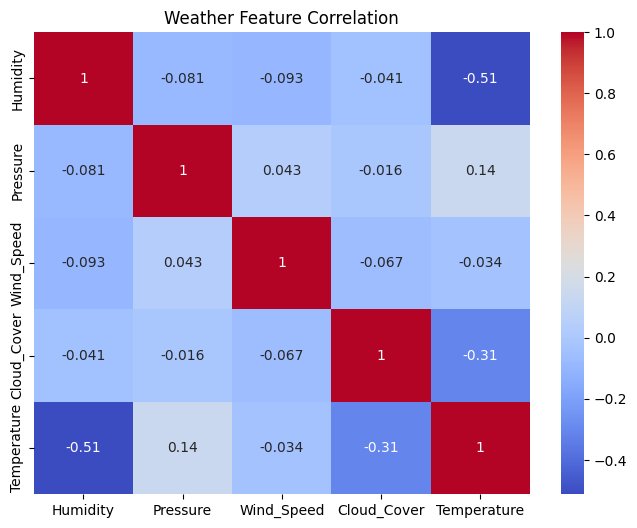

Training samples: 240
Testing samples: 60
Linear Regression Results
-------------------------
R² Score: 0.25567923877386245
MAE: 1.673317650693318
RMSE: 2.2081721997708628
Random Forest Results
---------------------
R² Score: 0.08350293376582507
MAE: 1.9365626461335532
RMSE: 2.4502952100831137


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.255679,1.673318,2.208172
1,Random Forest,0.083503,1.936563,2.450295


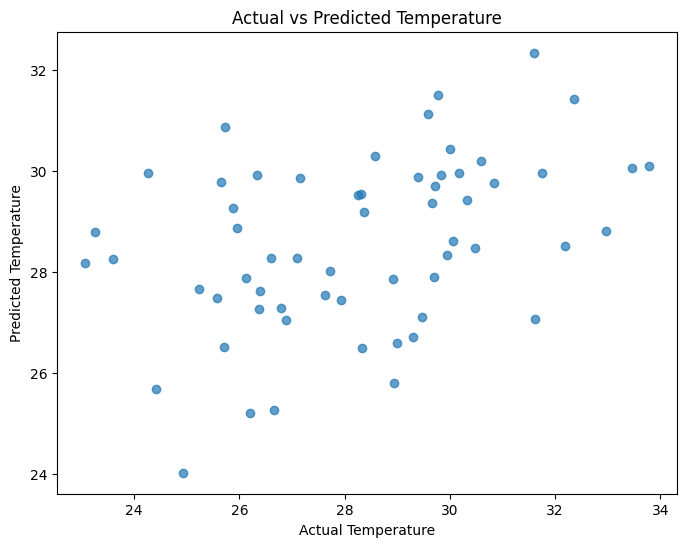

Enter Humidity (%): 20
Enter Pressure (hPa): 30
Enter Wind Speed (km/h): 50
Enter Cloud Cover (%): 50

🌡️ Predicted Temperature: 29.9 °C


In [1]:
import pandas as pd

import numpy as np



import matplotlib.pyplot as plt

import seaborn as sns



from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)



n = 300



humidity = np.random.randint(30, 91, n)

pressure = np.random.randint(990, 1031, n)

wind_speed = np.random.randint(2, 31, n)

cloud_cover = np.random.randint(0, 101, n)



temperature = (

    35

    - 0.08 * humidity

    + 0.03 * (pressure - 1000)

    - 0.04 * wind_speed

    - 0.03 * cloud_cover

    + np.random.normal(0, 2, n)

)



weather = pd.DataFrame({

    "Humidity": humidity,

    "Pressure": pressure,

    "Wind_Speed": wind_speed,

    "Cloud_Cover": cloud_cover,

    "Temperature": temperature

})



weather.head()

print("Dataset Shape:", weather.shape)



print("\nDataset Information:")

weather.info()



print("\nStatistical Summary:")

display(weather.describe())

print(weather.isnull().sum())

plt.figure(figsize=(8,6))



sns.heatmap(

    weather.corr(),

    annot=True,

    cmap="coolwarm"

)



plt.title("Weather Feature Correlation")



plt.show()

X = weather[

    [

        "Humidity",

        "Pressure",

        "Wind_Speed",

        "Cloud_Cover"

    ]

]



y = weather["Temperature"]



X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)



print("Training samples:", len(X_train))

print("Testing samples:", len(X_test))

linear_model = LinearRegression()



linear_model.fit(X_train, y_train)



linear_predictions = linear_model.predict(X_test)



linear_r2 = r2_score(y_test, linear_predictions)

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))



print("Linear Regression Results")

print("-------------------------")

print("R² Score:", linear_r2)

print("MAE:", linear_mae)

print("RMSE:", linear_rmse)

rf_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)



rf_model.fit(X_train, y_train)



rf_predictions = rf_model.predict(X_test)



rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))



print("Random Forest Results")

print("---------------------")

print("R² Score:", rf_r2)

print("MAE:", rf_mae)

print("RMSE:", rf_rmse)

comparison = pd.DataFrame({

    "Model": [

        "Linear Regression",

        "Random Forest"

    ],

    "R2 Score": [

        linear_r2,

        rf_r2

    ],

    "MAE": [

        linear_mae,

        rf_mae

    ],

    "RMSE": [

        linear_rmse,

        rf_rmse

    ]

})



display(comparison)

plt.figure(figsize=(8,6))



plt.scatter(

    y_test,

    rf_predictions,

    alpha=0.7

)



plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")



plt.title("Actual vs Predicted Temperature")



plt.show()

humidity = float(input("Enter Humidity (%): "))

pressure = float(input("Enter Pressure (hPa): "))

wind = float(input("Enter Wind Speed (km/h): "))

cloud = float(input("Enter Cloud Cover (%): "))



new_data = pd.DataFrame({

    "Humidity": [humidity],

    "Pressure": [pressure],

    "Wind_Speed": [wind],

    "Cloud_Cover": [cloud]

})



prediction = rf_model.predict(new_data)



print("\n🌡️ Predicted Temperature:", round(prediction[0], 2), "°C")

